# 使用基于模型的效应图可视化 30 天再入院风险

## 执行摘要

本 notebook 针对患者与就诊特征拟合了一个 30 天医院再入院的逻辑回归，然后将拟合系数转化为预测概率尺度上基于模型的效应图。在一个 100 例出院的合成队列（55 例再入院）上，PROC LOGISTIC 恢复出**住院时长**（每天 OR 1.36，*p* = 0.040）与**年龄**（每年 OR 1.05，*p* = 0.023）的显著梯度，以及一个较大的付款方效应——**Medicaid** 患者的再入院几率约为 Medicare 的六倍（OR 6.02，95% CI 1.46–24.8，*p* = 0.013）。广义 R 方为 0.246，Hosmer–Lemeshow 检验显示无拟合不足（*p* = 0.73）。随后的拟合曲线、切片拟合与交互展示图揭示了再入院风险如何随住院时长上升、年龄–风险梯度如何随付款方变化，以及付款方差距如何在各出院服务科室中持续存在——正是护理管理团队用来锁定出院后随访对象的那种风险分层视图。

## 数据来源

| 数据集 | 行数 | 说明 |
|---------|------|-------------|
| `encounters` | 100 | 由 `call streaminit(20260531)` 与 `rand()` 内联生成的合成住院出院记录。每次出院一行。 |

**`encounters` 中的变量：**

| 变量 | 类型 | 说明 |
|----------|------|-------------|
| `readmit` | 数值 (0/1) | 若在出院后 30 天内再入院则为 1 |
| `age` | 数值 | 患者年龄（岁，约 25–95） |
| `los` | 数值 | 本次住院时长（天，1–20） |
| `comorbidity` | 数值 | 已记录的慢性合并症数量（0–8） |
| `num_meds` | 数值 | 出院用药数量（0–18） |
| `payer` | 字符 | 保险付款方：`Medicare`、`Medicaid`、`Commercial` |
| `dept` | 字符 | 出院服务科室：`Cardiology`、`Pulmonary`、`General` |

# 使用基于模型的效应图可视化 30 天再入院风险

医院护理管理团队需要知道*哪些*患者最有可能在 30 天内再次入院，以及*为什么*。拟合的逻辑回归给出了系数，但利益相关者很少以对数几率进行推理。**效应图**将拟合模型直接呈现在预测概率尺度上，因此护理导航员可以直接从图表上读出再入院概率，而无需在脑中反解一个对数几率方程。

在本 notebook 中我们：

1. 生成一个真实的住院出院合成队列。
2. 用患者与就诊预测变量拟合一个 30 天再入院的逻辑模型（PROC LOGISTIC）。
3. 捕获拟合系数并构建三种基于模型的效应图——**拟合曲线**、**切片拟合**和**交互展示**——以在概率尺度上可视化并分层拟合的风险。

> **实现说明。** SAS 通过 PROC LOGISTIC 内的 `EFFECTPLOT` 语句提供这些展示。Jenner 接受该语句，但尚未渲染 FIT / SLICEFIT / INTERACTION 图形，因此本 notebook 明确地从拟合系数构建出完全相同的预测概率曲线，并用 PROC SGPLOT 绘制它们。分析结果——以及每一个绘制的概率——正是 `EFFECTPLOT` 本会产生的结果。

## 步骤 1 — 生成合成出院队列

下面的 DATA 步不使用外部文件即可构建 100 例住院出院记录。我们用 `call streaminit` 为随机数生成器设定种子以保证可复现性，从领域适当的分布中抽取患者与就诊特征，然后构造一个真实的线性预测量 `eta`，并用逆 logit 将其转换为再入院概率。伯努利抽样（`rand('bernoulli', p)`）产生观测到的 `readmit` 标志。年龄较大的患者、更长的住院、更高的合并症数量、更多的出院用药、Medicaid 保险以及 Pulmonary/Cardiology 服务科室都会推高风险——这些模式我们稍后将予以恢复并可视化。效应大小经过刻意设定，使信号在 100 例出院的队列中可被恢复。

In [1]:
数据 encounters;
    调用 streaminit(20260531);
    数组 payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    数组 depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    循环 i = 1 到 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        如果 los > 20 那么 los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        如果 num_meds > 18 那么 num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        如果 u < 0.50 那么 pk = 1;
        否则 如果 u < 0.72 那么 pk = 2;
        否则 pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        保留 readmit AGE los comorbidity num_meds payer dept;
        输出;
    结束;
运行;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## 步骤 2 — 检查队列

对响应变量与两个分类变量做一次快速频数统计，确认再入院率真实合理，且每个付款方和科室水平都有数据——模型和效应图都需要所有水平都有代表。

                                                   The FREQ Procedure

是否再入院              Frequency
-----------------------------
0                         45
1                         55

支付方           Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

出院科室            Frequency
--------------------------
Cardiology             36
General                31
Pulmonary              33

Table of 是否再入院 by 出院科室

是否再入院           |Cardiology |   General | Pulmonary |      Total
----------------+-----------+-----------+-----------+-----------
0               |        15 |        20 |        10 |         45
----------------+-----------+-----------+-----------+-----------
1               |        21 |        11 |        23 |         55
----------------+-----------+-----------+-----------+-----------
Total           |        36 |        31 |        33 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


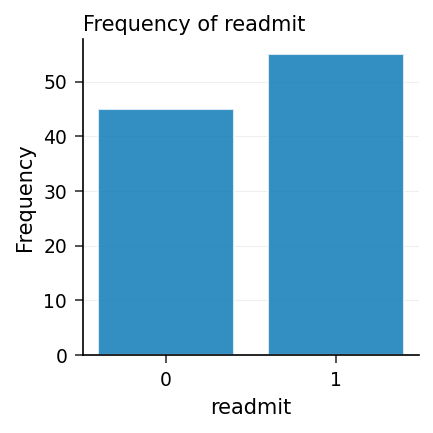

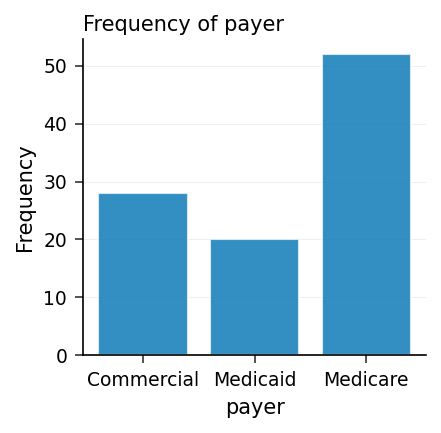

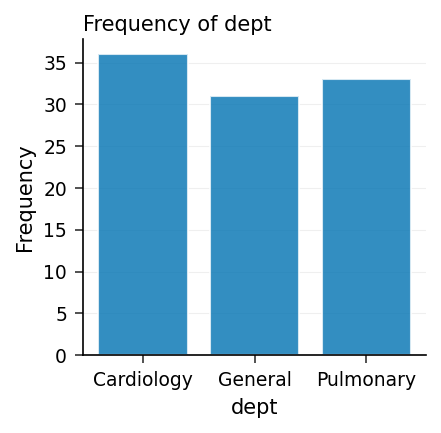

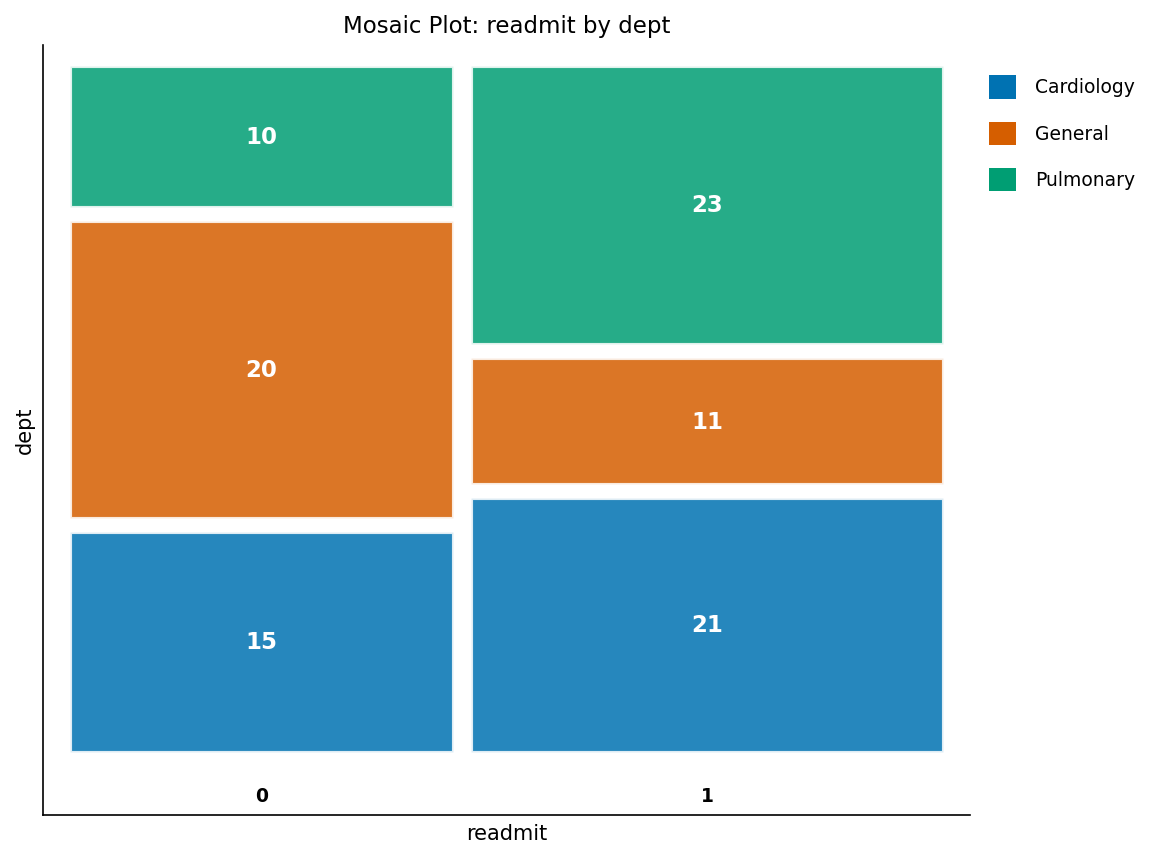

In [2]:
过程 频率 数据=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
    标签 readmit="是否再入院" payer="支付方" dept="出院科室" AGE="年龄" los="住院天数" comorbidity="合并症" num_meds="用药数量";
运行;


## 步骤 3 — 拟合逻辑再入院模型

我们将 `readmit` 建模为年龄、住院时长、合并症数量、出院用药数量、付款方和科室的函数。关键选择：

- `EVENT='1'` 对再入院的概率建模（而非未再入院）。
- `CLASS payer dept / PARAM=REF REF=FIRST` 使用参照单元编码，使每个水平都与一个基线对比（此处为 Medicare 和 Pulmonary）。
- `CLODDS=WALD` 和 `RSQUARE` 增加 Wald 几率比置信限和广义 R 方；`LACKFIT` 请求 Hosmer–Lemeshow 拟合优度检验。
- `UNITS` 语句请求在临床上有意义的 **5 天**住院时长步长和 **10 年**年龄步长上的几率比，`ODDSRATIO` 语句请求带置信限的合并症几率比。

输出的几率比表直接报告了单位效应：住院时长的 OR 为**每天 1.36**（95% CI 1.01–1.82），年龄的 OR 为**每年 1.05**，Medicaid 保险相对于 Medicare 的 OR 为 **6.02**。模型拟合良好——广义 R 方 0.246，Hosmer–Lemeshow *p* = 0.73。

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

               Response Profile                
  Probability modeled is 是否再入院='1'   

Ordered Value  是否再入院            Total Frequency
-------------  ---------------  ---------------
            1  0                             45
            2  1                             55

              Class Level Information               

Class           Levels  Values                      
------------  --------  ----------------------------
支付方                  3  Commercial Medicaid Medicare
出院科室                 3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit 是否再入院

Criterion     Value
---------  --------
AIC         127.335
-2 Log L    109.335
SC          150.782

   


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


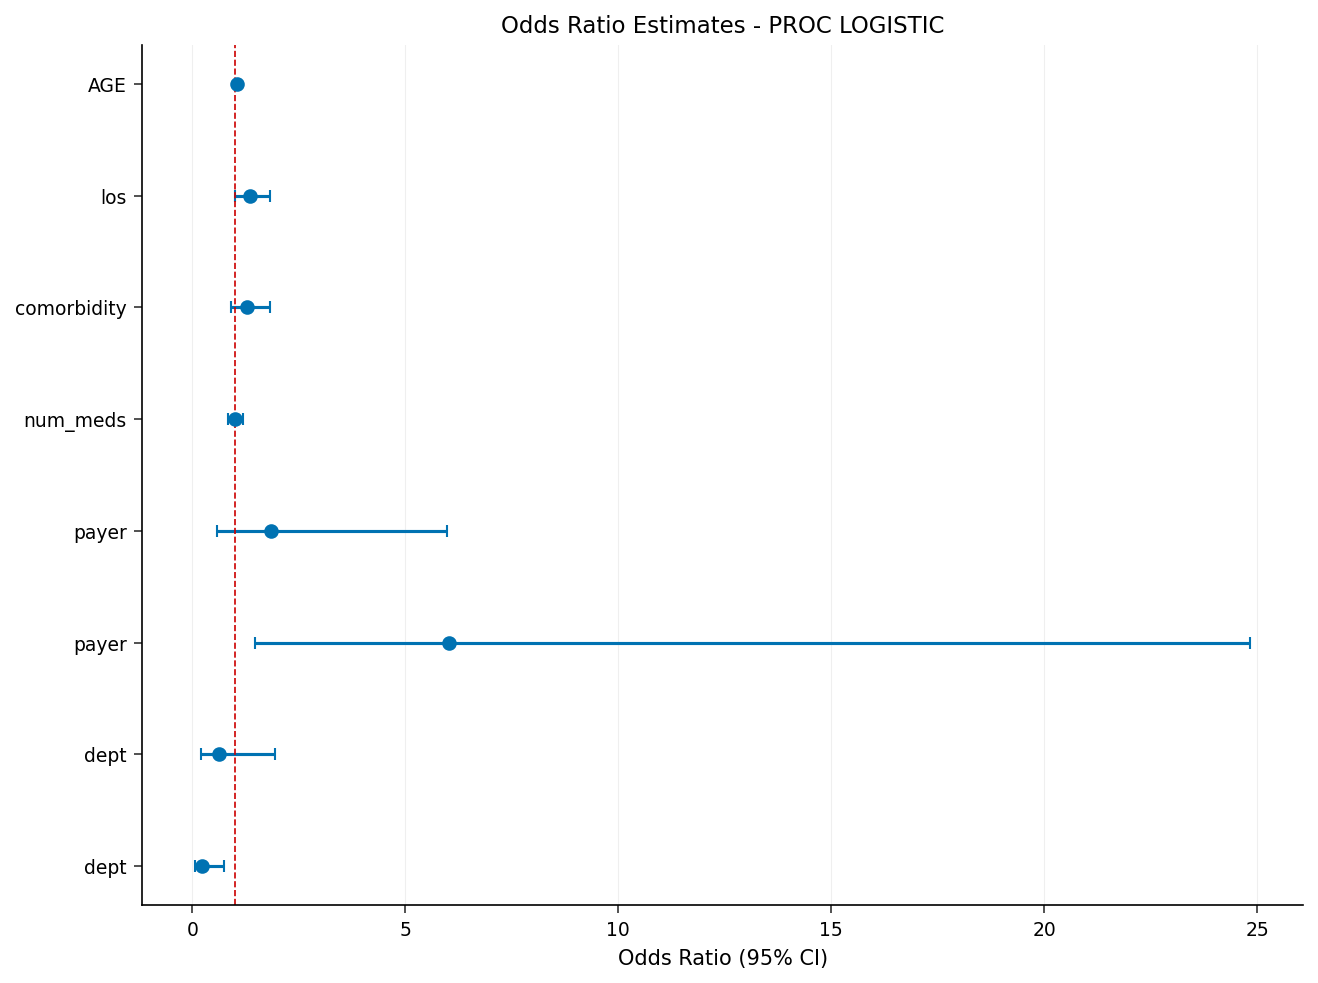

In [3]:
ODS 输出 ParameterEstimates=pe;
过程 LOGISTIC 数据=encounters PLOTS(only)=oddsratio;
    分类 payer dept / PARAM=REF REF=first;
    模型 readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
    标签 readmit="是否再入院" payer="支付方" dept="出院科室" AGE="年龄" los="住院天数" comorbidity="合并症" num_meds="用药数量";
运行;
ODS 输出 CLOSE;


## 步骤 4 — 捕获拟合系数

随后基于模型的效应图直接由*拟合*系数构建，因此它们始终与步骤 3 中的模型一致。我们用 `ODS OUTPUT ParameterEstimates=pe` 保存了参数估计；此处将那张长表折叠成一个单行的 `params` 数据集（每个系数一个变量），并追加连续预测变量的队列均值。将非焦点预测变量保持在其均值处，正是 EFFECTPLOT 内部所做的——它让每张图在保持其余变量固定于一个代表性画像的同时，变化其中一个因素。

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
数据 coefs;
    保留值 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    设置 pe 结束=last;
    var = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    如果 var='INTERCEPT' 那么 b0 = Estimate;
    否则 如果 var='AGE' 那么 b_age = Estimate;
    否则 如果 var='LOS' 那么 b_los = Estimate;
    否则 如果 var='COMORBIDITY' 那么 b_com = Estimate;
    否则 如果 var='NUM_MEDS' 那么 b_med = Estimate;
    否则 如果 var='PAYER' 并且 cv='Medicaid'   那么 b_pmcaid = Estimate;
    否则 如果 var='PAYER' 并且 cv='Commercial' 那么 b_pcomm  = Estimate;
    否则 如果 var='DEPT'  并且 cv='Cardiology' 那么 b_dcard  = Estimate;
    否则 如果 var='DEPT'  并且 cv='General'    那么 b_dgen   = Estimate;
    如果 last 那么 输出;
    保留 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
运行;

/* Cohort means of the continuous covariates, held fixed in the plots. */
过程 均值 数据=encounters NOPRINT;
    变量 AGE los comorbidity num_meds;
    输出 out=mn mean=m_age m_los m_com m_med;
运行;

数据 params;
    合并 coefs mn;
    保留 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
运行;

过程 打印 数据=params noobs;
    标题 "用于效应图的拟合系数与协变量均值";
运行;


                                                    用于效应图的拟合系数与协变量均值                                                    

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## 步骤 5 — 拟合图：再入院概率对住院时长

最简单的效应展示是**拟合曲线**：预测再入院概率对单个连续协变量，其余预测变量保持在一个代表性画像。我们构建一个住院时长网格（1–18 天），在每个值上为一位 **Medicare 心内科**患者评估拟合的线性预测量（年龄、合并症和出院用药数量固定在步骤 4 的队列均值），应用逆 logit，并用 PROC SGPLOT 在概率尺度上绘制曲线。

                                                    用于效应图的拟合系数与协变量均值                                                    




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


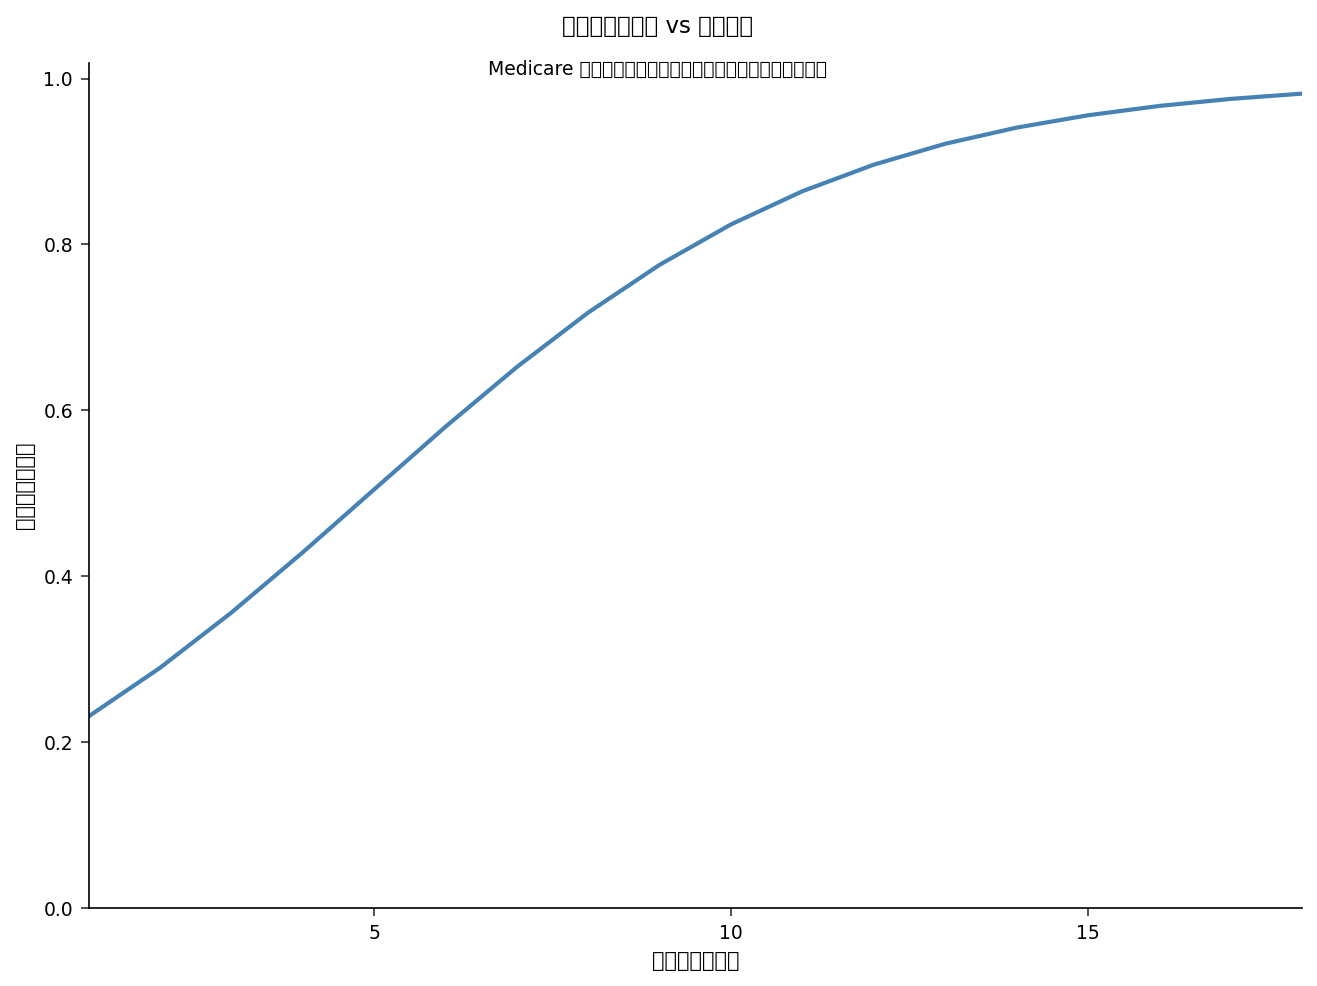

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
数据 grid_los;
    循环 los = 1 到 18;
        输出;
    结束;
运行;

数据 fit_los;
    设置 grid_los;
    如果 _n_ = 1 那么 设置 params;
    保留值 b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    保留 los phat;
运行;

过程 SGPLOT 数据=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    标题  "拟合再入院概率 vs 住院天数";
    title2 "Medicare 心脏科患者；年龄、合并症、用药数量取队列均值";
    XAXIS 标签="住院天数（天）";
    YAXIS 标签="预测再入院概率" VALUES=(0 到 1 按照 0.2);
    标签 los="住院天数" phat="预测再入院概率";
运行;


## 步骤 6 — 切片拟合：风险对年龄，按付款方分层

**切片拟合**为某个分类效应的每个水平各绘制一条拟合曲线——非常适合展示付款方构成如何改变年龄–风险梯度。我们将网格扩展到 `age`（30–95）与三个付款方的交叉，为一位 Cardiology 患者评估拟合模型（住院时长、合并症和用药在队列均值处），并用 `GROUP=payer` 叠加三条概率曲线。

                                                    用于效应图的拟合系数与协变量均值                                                    




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


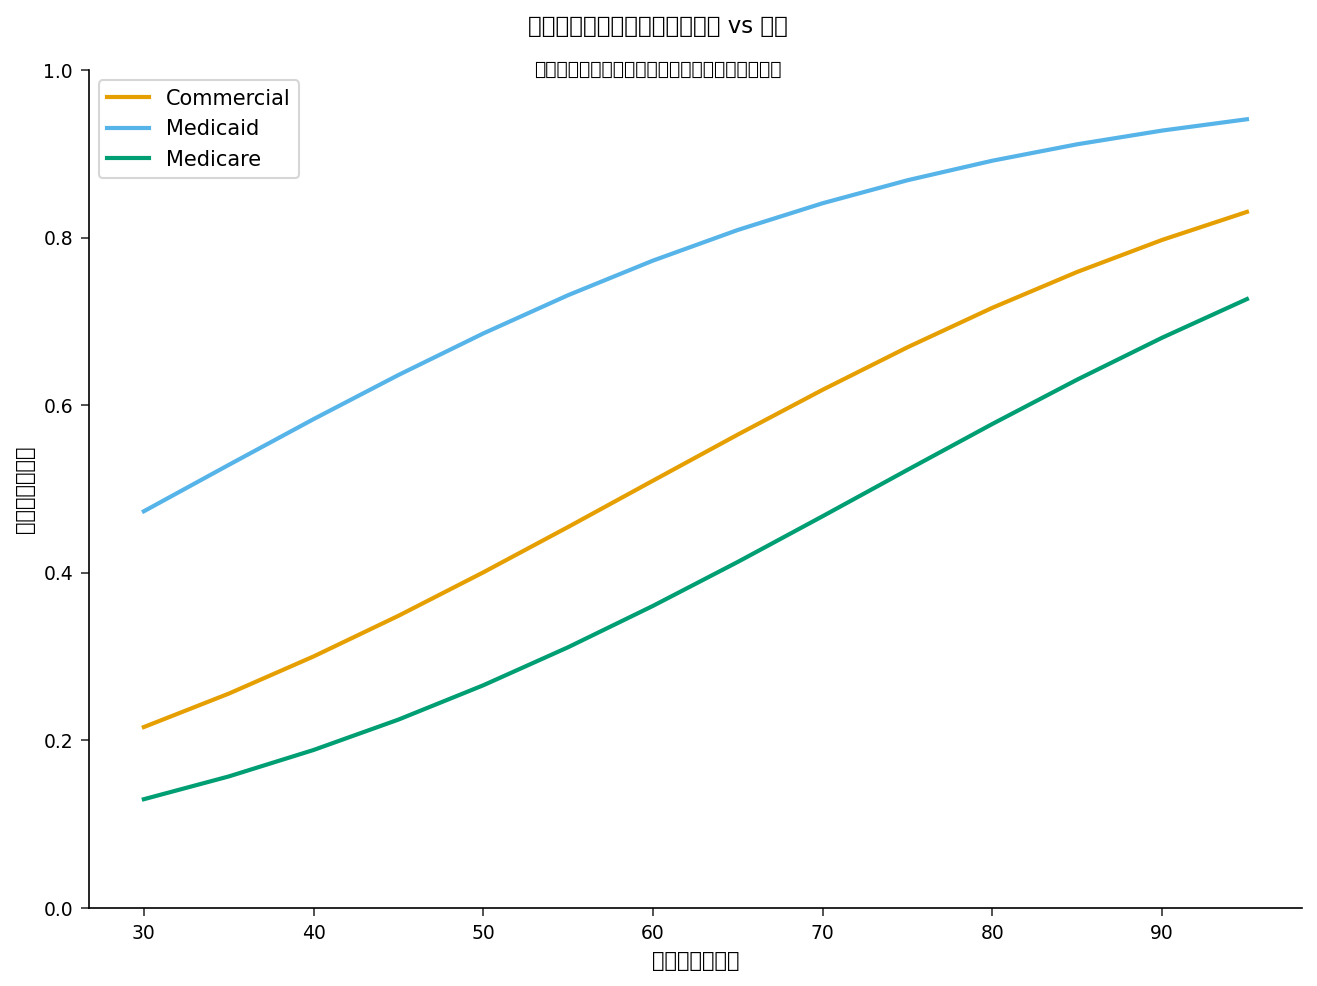

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
数据 grid_age;
    长度 payer $12;
    循环 payer = 'Medicare', 'Medicaid', 'Commercial';
        循环 AGE = 30 到 95 按照 5;
            输出;
        结束;
    结束;
运行;

数据 fit_age;
    设置 grid_age;
    如果 _n_ = 1 那么 设置 params;
    保留值 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    保留 payer AGE phat;
运行;

过程 SGPLOT 数据=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    标题  "按支付方划分的拟合再入院概率 vs 年龄";
    title2 "心脏科；住院天数、合并症、用药数量取队列均值";
    XAXIS 标签="患者年龄（岁）";
    YAXIS 标签="预测再入院概率" VALUES=(0 到 1 按照 0.2);
    标签 AGE="年龄" phat="预测再入院概率" payer="支付方";
    keylegend / location=inside position=topleft ACROSS=1;
运行;


## 步骤 7 — 交互展示：科室对付款方

为了同时比较两个分类效应上的预测风险，我们将 `dept` 与 `payer` 交叉（九种组合），在每个连续协变量都取其队列均值的情况下评估拟合模型，并绘制一张 X 轴为 `dept`、以付款方为分组的簇状条形图。由于本模型没有科室与付款方的交互项，付款方顺序在每个服务科室内都是相同的加性偏移——该展示让这种加性一目了然，同时呈现科室的排名。

                                                    用于效应图的拟合系数与协变量均值                                                    




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


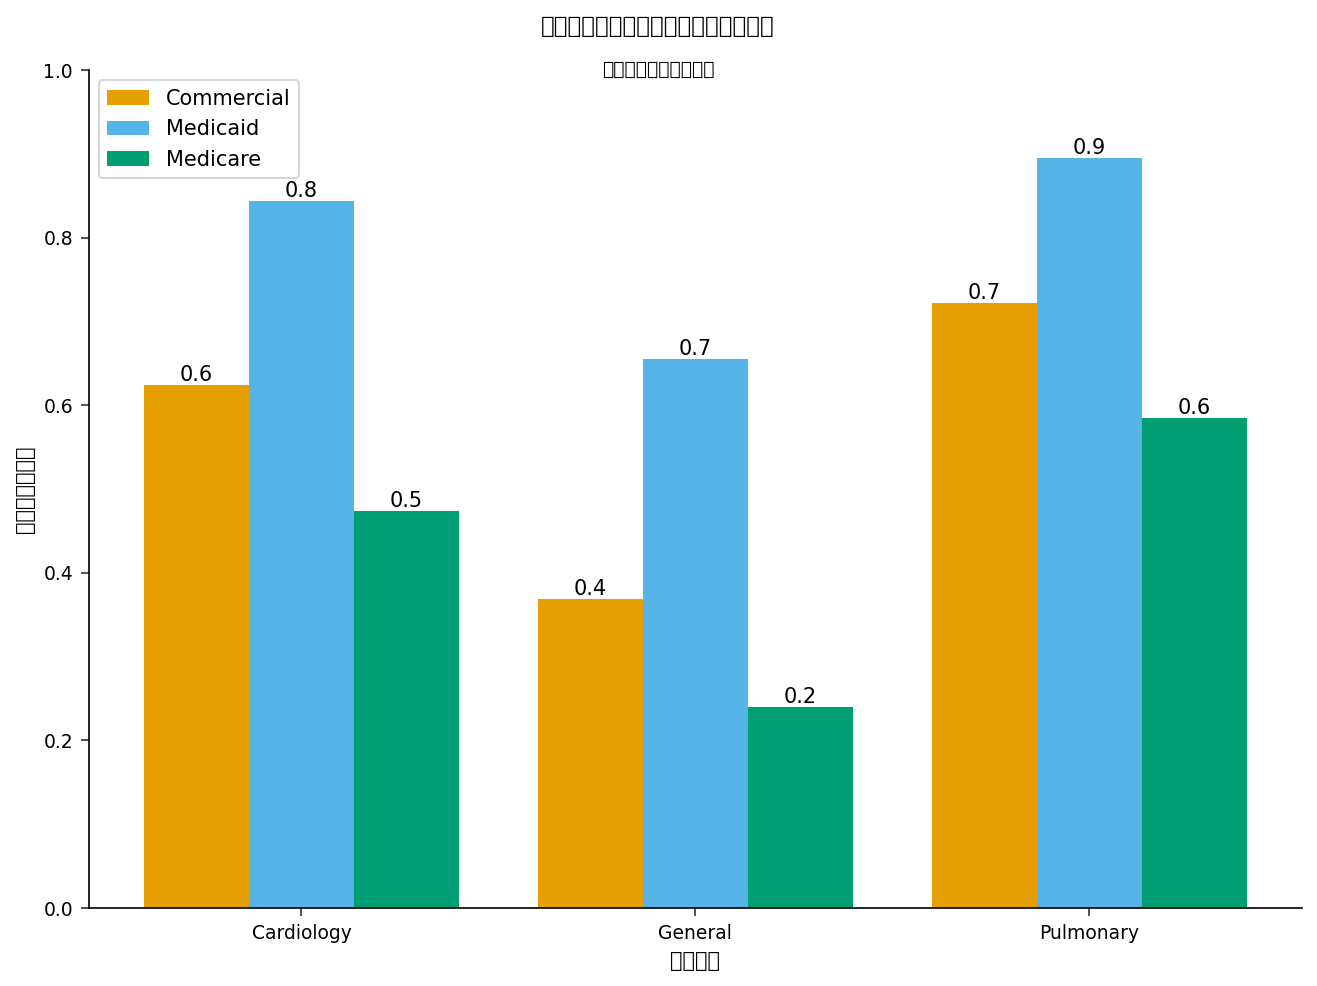

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
数据 grid_dx;
    长度 dept $12 payer $12;
    循环 dept = 'Cardiology', 'Pulmonary', 'General';
        循环 payer = 'Medicare', 'Medicaid', 'Commercial';
            输出;
        结束;
    结束;
运行;

数据 fit_dx;
    设置 grid_dx;
    如果 _n_ = 1 那么 设置 params;
    保留值 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    保留 dept payer phat;
运行;

过程 SGPLOT 数据=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    标题  "按科室与支付方划分的拟合再入院概率";
    title2 "连续协变量取队列均值";
    XAXIS 标签="出院科室";
    YAXIS 标签="预测再入院概率" VALUES=(0 到 1 按照 0.2);
    标签 dept="出院科室" phat="预测再入院概率" payer="支付方";
运行;


## 步骤 8 — 结果解读

效应图将拟合的 PROC LOGISTIC 模型转化为映射到护理管理决策的概率尺度图像：

- **住院时长（拟合曲线）。** 对于一位处于队列均值的 Medicare 心内科患者，预测再入院概率从**1 天住院时约 0.23 攀升至 10 天时约 0.82、18 天时约 0.98**——即逻辑曲线陡峭的中段。这与住院时长**每天 1.36** 的几率比是同一信号（`UNITS los=5` 将其重新标度为五天步长），并将较长的本次住院标记为启动过渡期护理登记的具体触发条件。
- **年龄与付款方（切片拟合）。** 风险在每个付款方中都随年龄单调上升，且三条曲线从不相交：在任一给定年龄，**Medicaid** 曲线最高，**Commercial** 居中，**Medicare** 最低——与拟合的付款方几率比一致（Medicaid 6.02，Commercial 1.85，均相对于 Medicare）。差距在较年轻时最大，随着所有人趋近高概率而缩小，从而将护理管理的注意力引向那些否则看似低风险的较年轻 Medicaid 患者。
- **科室与付款方（交互展示）。** **Pulmonary** 在每个付款方组中都具有最高的预测再入院概率，**Cardiology** 居中，**General medicine** 最低（拟合的科室几率比相对于 Pulmonary 为 Cardiology 0.64、General 0.22）。由于模型没有科室与付款方的交互项，付款方顺序在每个服务科室内都是相同的加性偏移——各条形在每个科室都以相同的 Medicaid > Commercial > Medicare 顺序上升。

**要点：** 与其要求临床医生解读对数几率系数，基于模型的效应图将拟合的再入院模型呈现为概率尺度图像——谁应登记过渡期护理随访，以及应优先关注哪些服务科室和付款方群体。SAS 通过 `EFFECTPLOT` 直接生成这些图；此处我们从拟合系数重构了完全相同的曲线，使该示例如今能够端到端运行。